# Signal and Image Processing (SIP) WS24

##  Hilbert Transform Tutorial

### Import packages

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## Analytic Signal

### Define plot function

In [12]:
# Function for plotting the signal, with parameters x (signal) and t (time array)
def plot_x(x,t):
    
    # Define figure size
    plt.figure(figsize=(15,5))
    # Plot the signal x in seconds
    plt.plot(t,x)
    # Label the axes
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (a.u.)')
    # Show grid in plot
    plt.grid()
    # Show the plot
    plt.show()
    

### Generate a sine signal and plot it

In [53]:
# signal length (s)
T = 1
# sampling frequency in Hz
fs = 1000
# signal frequency in Hz
f = 2

'''
TO-DO: define sine signal x with frequency f, length T and sampling frequency fs
'''
# signal length (samples)
N = T*fs
# sample indices array
n = np.arange(N)
# Add amplitude
A = 1
# sine signal
x = A*np.sin(2*np.pi*f/fs*n)

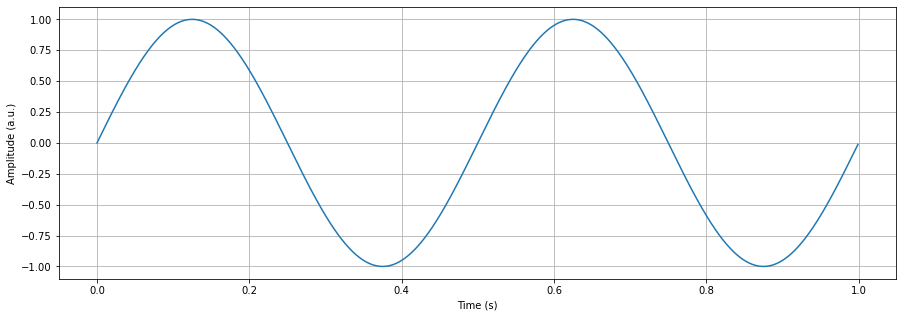

In [44]:
'''
TO-DO: define time array t correctly; what are our discrete steps n = 0,...,N in terms of time?
'''

# Define time array
t = n/fs

# Plot the signal x
plot_x(x,t)

### Calculate the analytic signal z

In [27]:
def analytic_signal(x):
        
    '''
    TO-DO: Apply Hilbert transform (see steps in lecture note)
    '''
    X = np.fft.fft(x)
    half_len = int(len(x)/2)
    X[:half_len] = 2*X[:half_len]
    X[half_len:] = 0
    z = np.fft.ifft(X)
    
    return(z)

In [54]:
z = analytic_signal(x)

### Calculate and plot instantaneous amplitude, phase and frequency

In [51]:
def plot_z(z, t, fs, freq_lim = None):
    
    # Calculate instantaneous amplitude, and real and imaginary part of z
    real_z = np.real(z)
    imag_z = np.imag(z)
    inst_amp = np.abs(z) 
    '''    
    TO-DO: calculate real_z, imag_z and inst_amp
    '''
    
    # Calculate instantaneous phase
    inst_phase = np.angle(z) 
    '''
    TO-DO: calculate inst_phase (replace RHS above)
    '''
    
    # Calculate instantaneous frequency
    inst_freq = np.diff(np.unwrap(inst_phase))/(2*np.pi)*fs
    '''
    TO-DO: calculate inst_freq (convert from radians in Hz)
    '''
    
    
    # Define figure size
    plt.figure(figsize=(15,10))
    
    # First Subplot with instantaneous amplitude, real and imaginary part of z
    plt.subplot(3,1,1)
    plt.plot(t, real_z, label='real')
    plt.plot(t, imag_z, label='imag')
    plt.plot(t, inst_amp, label='inst amp')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (a.u.)')
    plt.legend()
    plt.grid()
    
    # Second Subplot with instantaneous phase
    plt.subplot(3,1,2)
    plt.plot(t, inst_phase, label='inst phase', color='red')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (a.u.)')
    plt.legend()
    plt.grid()
    
    # Third Subplot with instantaneous frequency
    plt.subplot(3,1,3)
    plt.plot(t[1:], inst_freq, label='inst freq', color='purple')
    # Set y-lim to avoid rounding errors and computational artefacts
    if freq_lim is not None:
        plt.ylim(freq_lim)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (a.u.)')
    plt.legend()
    plt.grid()

### Plot analytic signal z in time domain

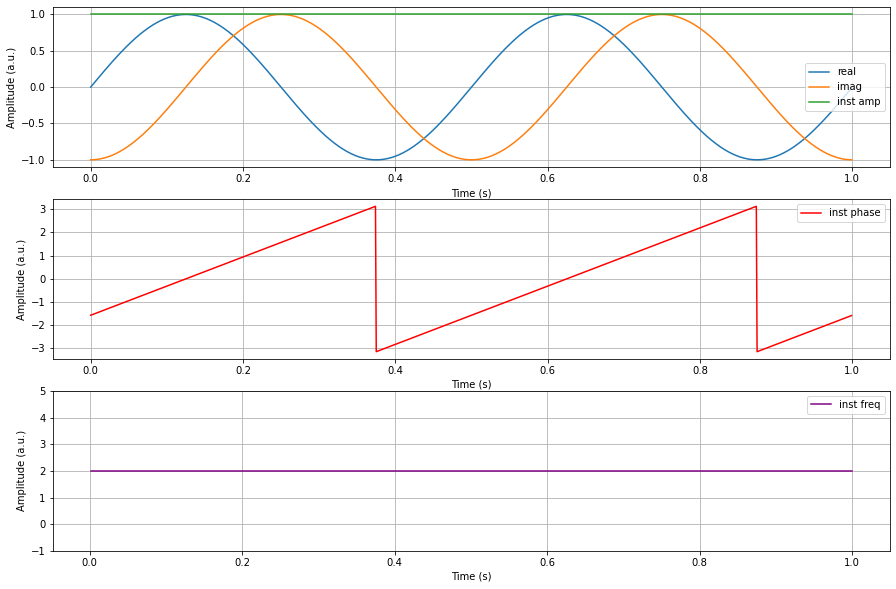

In [55]:
# Plot the instantaneous amplitude, phase and frequency  
plot_z(z, t, fs, [-1,5])

### Plot analytic signal z in complex plane

In [39]:
def scatter_z(z):
    colors = cm.rainbow(np.linspace(0,1,len(z)))
    plt.figure(figsize=(10,10))
    plt.axhline(0, c='k')
    plt.axvline(0, c='k')
    plt.scatter(np.real(z), np.imag(z), color=colors)
    plt.xlabel('real(z)')
    plt.ylabel('imag(z)')
    plt.grid()
    plt.show()

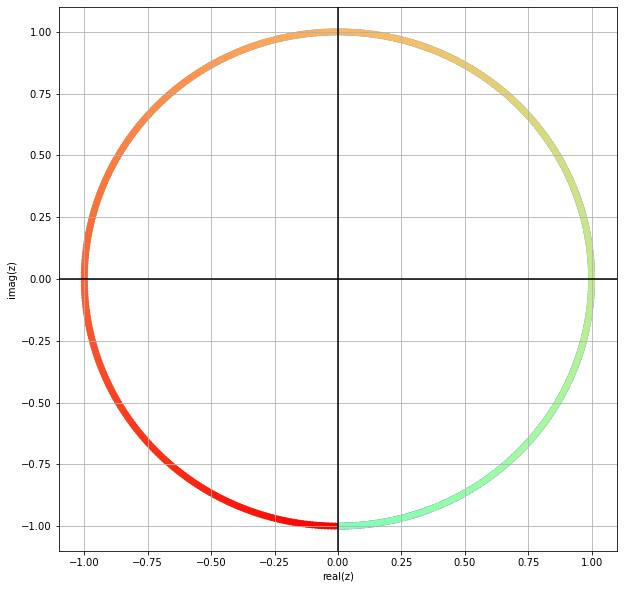

'\nThe signal starts at color purple\n'

In [56]:
# Scatter plot
scatter_z(z)

'''
The signal starts at color purple
'''

### Signal with 2 frequency components

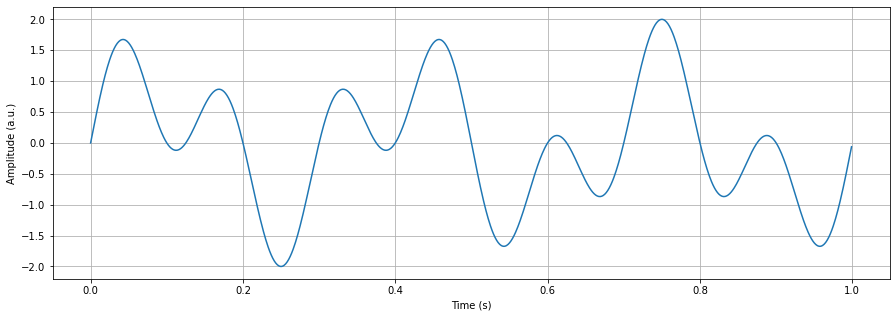

In [57]:
#Two frequency components
f1 = 7
f2 = 3

# Sum of two sine waves
x2 = np.sin(2*np.pi*f1*n/fs) + np.sin(2*np.pi*f2*n/fs)
'''
TO-DO: define sine signal x2 with two frequency components f1 and f2
'''

# Plot the signal
plot_x(x2,t)

### Calculate and plot instantantaneous amplitude, phase and frequency of new signal

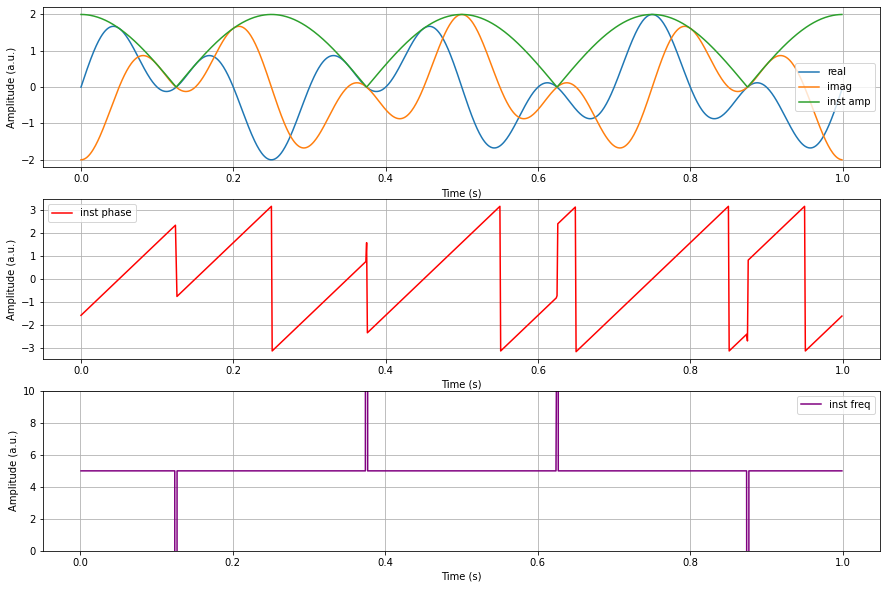

In [58]:
# Calculate z2
z2 = analytic_signal(x2)

# Plot inst ampl, phase and freq
plot_z(z2,t,fs,[0,10])

### Show complex plane

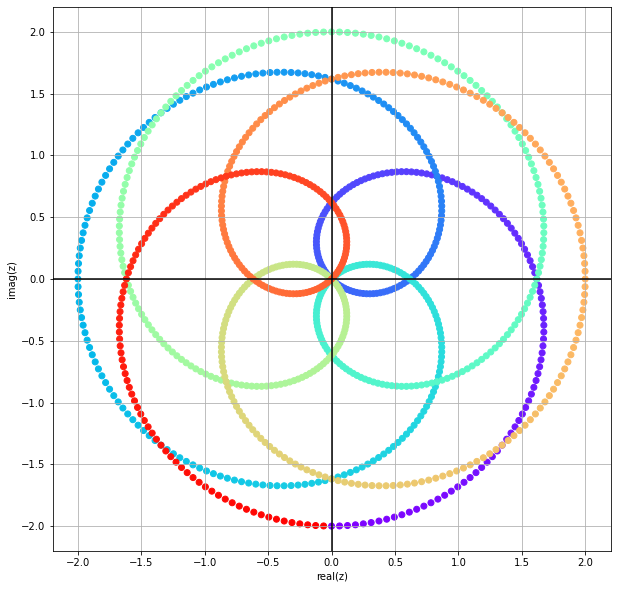

In [60]:
scatter_z(z2)

### More complex signal

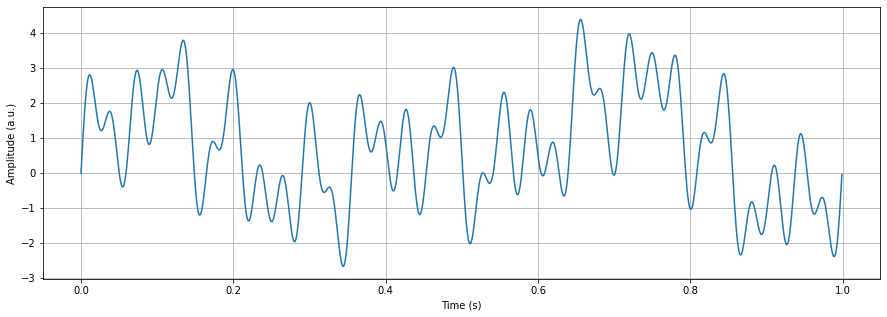

In [62]:
# Six frequency components
freqs = [0.3,1.9,3,11,17,31]

# Sum up the individual freq. components
x3 = np.zeros(N)
for f in freqs:
    x3 += np.sin(2*np.pi*f*n/fs)
    '''
    TO-DO: define sine signal x3 with multiple frequency components
    '''

# Plot the new signal
plot_x(x3,t)

### Calculate and plot instantantaneous amplitude, phase and frequency of new signal

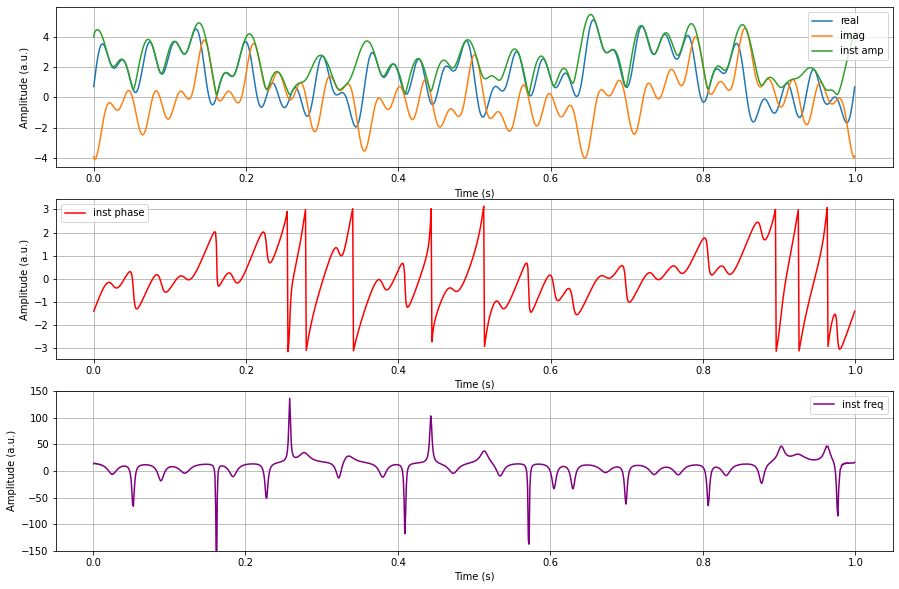

In [63]:
z3 = analytic_signal(x3)
plot_z(z3,t,fs,[-150,150])

### Show complex plane of new signal

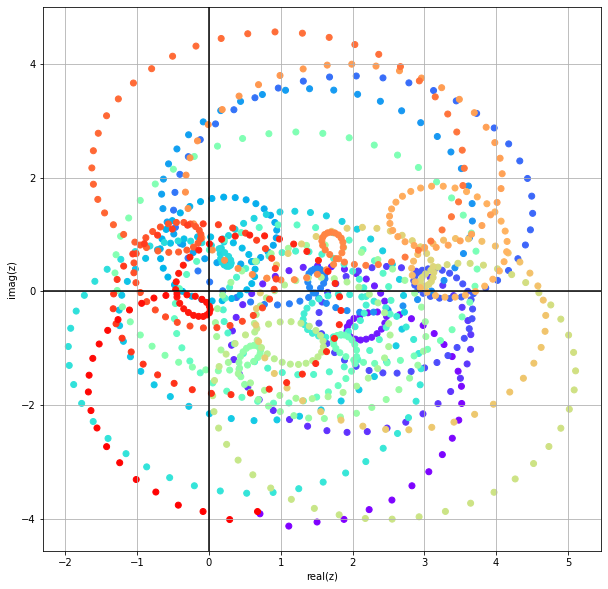

In [64]:
scatter_z(z3)

## Amplitude and Frequency Modulation

### Amplitude modulated signal

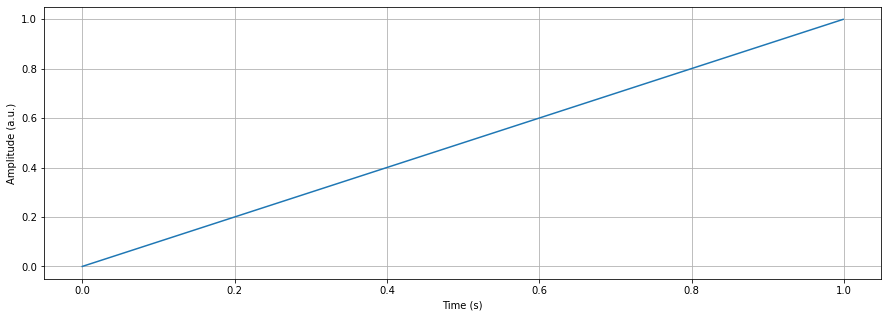

In [69]:
# amplitude modulated signal: combination of two signals

# modulator: signal we want to transmit (acutal interesting signal)
fm = 0.5

'''
Try both signals xm
'''
xm = np.sin(2*np.pi*fm/fs*n)
xm = np.arange(N)/N 

plot_x(xm,t)

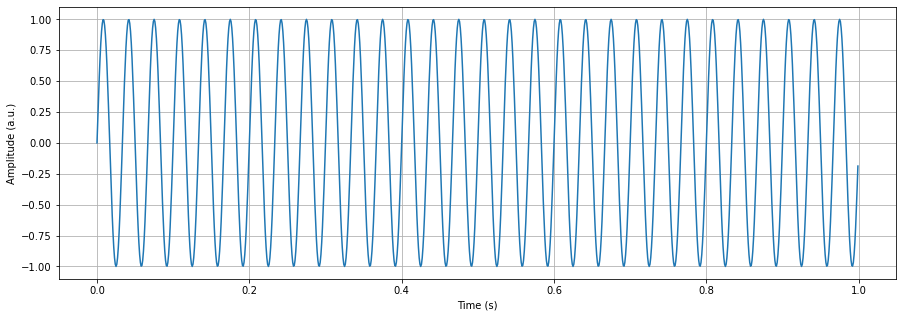

In [76]:
# carrier: signal, that carries our interesting signal (transfer interesting signal onto)
fc = 30
xc = np.sin(2*np.pi*fc/fs*n)
'''
TO-DO: Define carrier signal xc
'''

plot_x(xc,t)

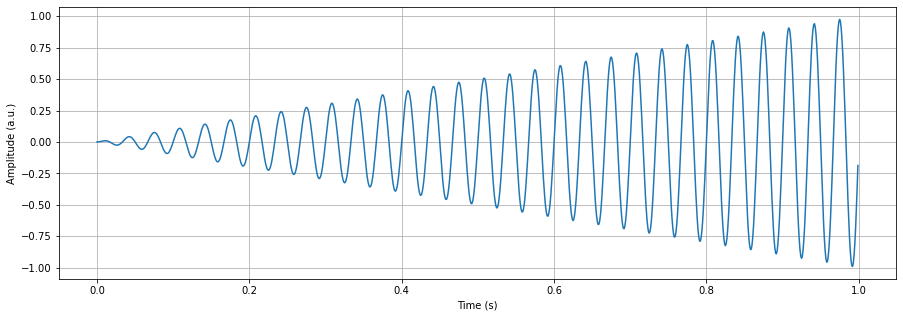

In [77]:
# Amplitdue modulated signal
x_am = xc * xm
'''
TO-DO: Calculate amplitude modulated signal x_am
'''

plot_x(x_am,t)

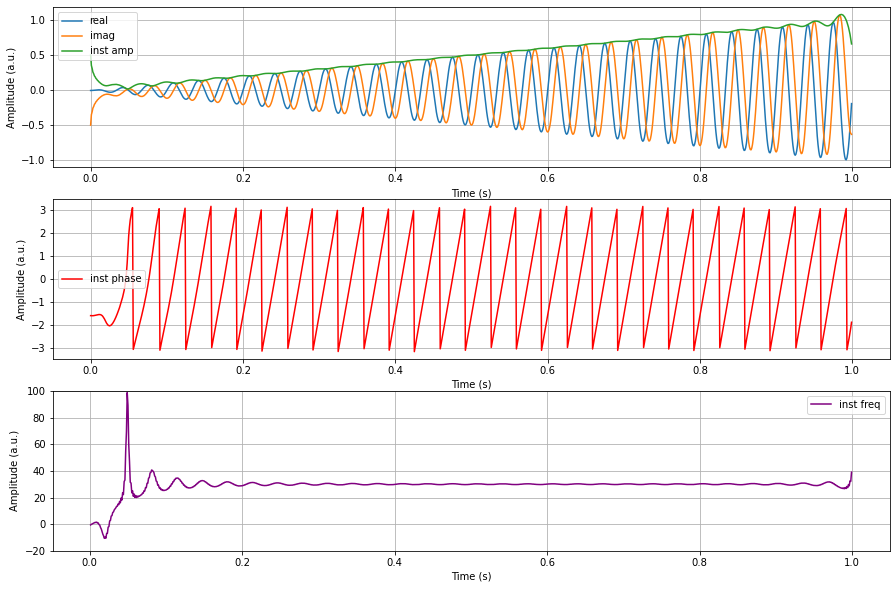

In [78]:
z_am = analytic_signal(x_am)
plot_z(z_am, t, fs, [-20,100])

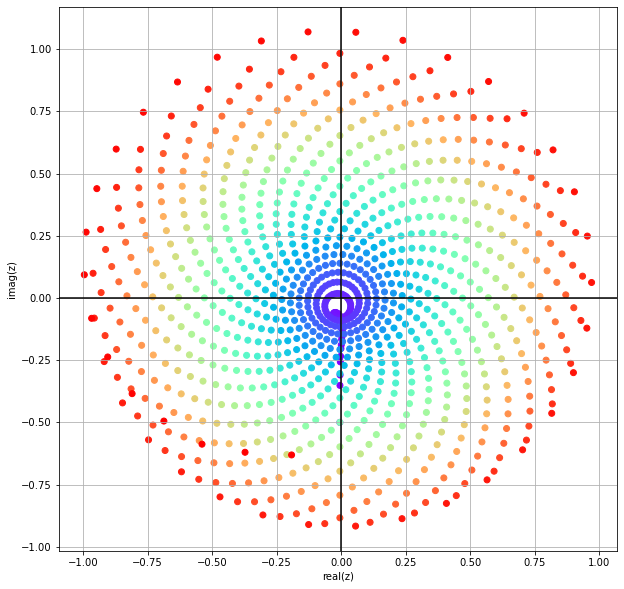

In [79]:
scatter_z(z_am)

### Frequency Modulation

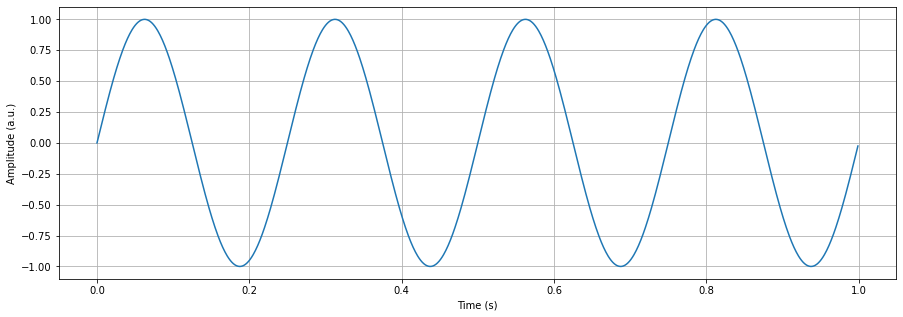

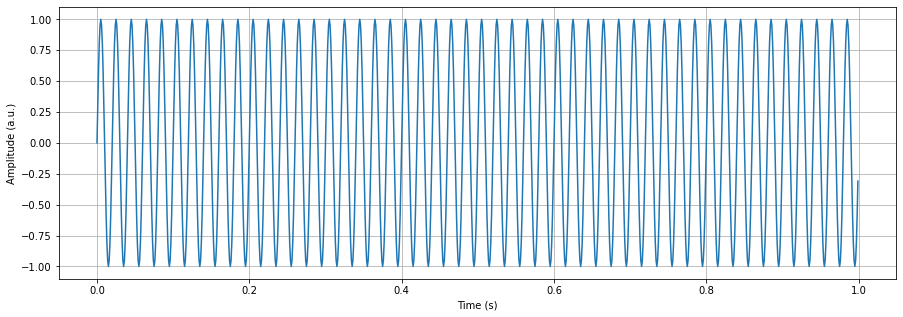

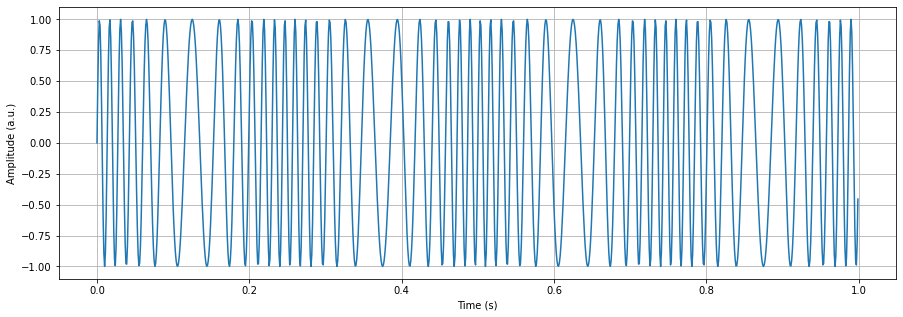

In [81]:
# frequency modulated signal

# modulator
fm = 4

'''
Try both signals xm
'''
# xm = np.zeros(N)
# xm[0:250] = np.arange(250)/250
# xm[250:750] = np.arange(250,-250,-1)/250
# xm[750:] = np.arange(-250,0)/250

xm = np.sin(2*np.pi*fm/fs*n)

# carrier
fc = 50
xc = np.sin(2*np.pi*fc/fs*n)
'''
TO-DO: Define carrier signal xc
'''

# modulation factor
mf = 1

# add modulator signal to phase of carrier signal
x_fm = np.sin(2*np.pi*fc/fs*n + 2*np.pi*xm*mf)
'''
TO-DO: Calculate frequency modulated signal (note that you now add the modulater signal to the phase)
'''

# Modulator signal
plot_x(xm,t)
# Carrier signal
plot_x(xc,t)

# Frequncy modulated signal
plot_x(x_fm,t)

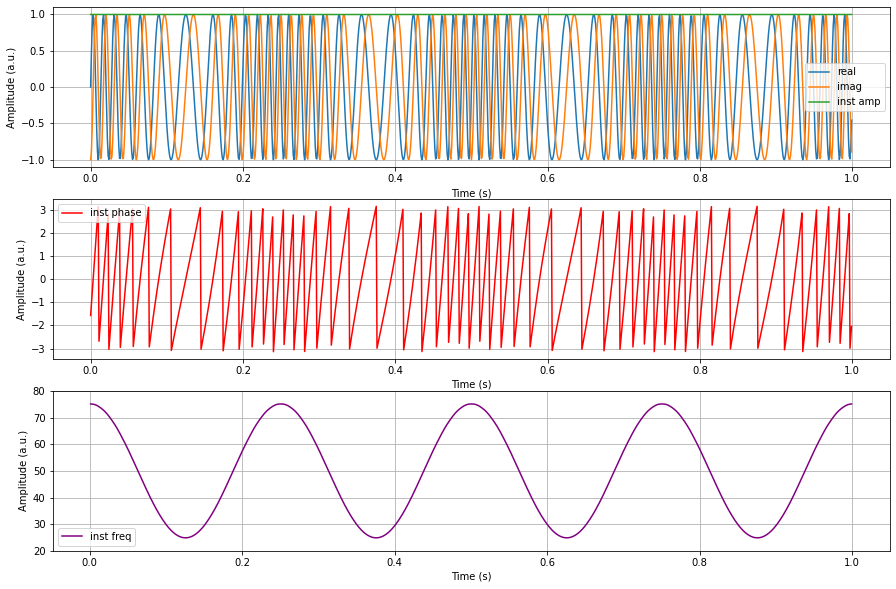

In [82]:
z_fm = analytic_signal(x_fm)
plot_z(z_fm,t,fs,[20,80])

### Demodulate signal

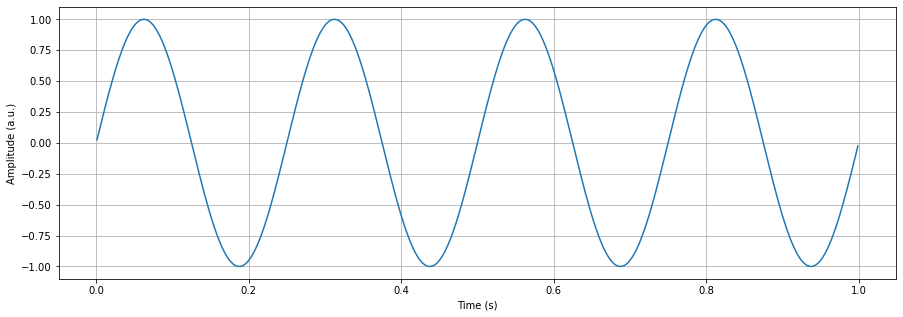

In [84]:
# Calculate inst. frequency
'''
TO-DO: Calculate inst. frequency inst_freq with unwrap
'''
inst_freq = np.diff(np.unwrap(np.angle(z_fm))) *fs /(2*np.pi)
# Demodulate: integral of inst freq
'''
TO-DO: Calculate integral of inst frequency (modulator factor!)
'''
xm_demod = np.cumsum(inst_freq-fc) /fs /mf

plot_x(xm_demod,t[1:])

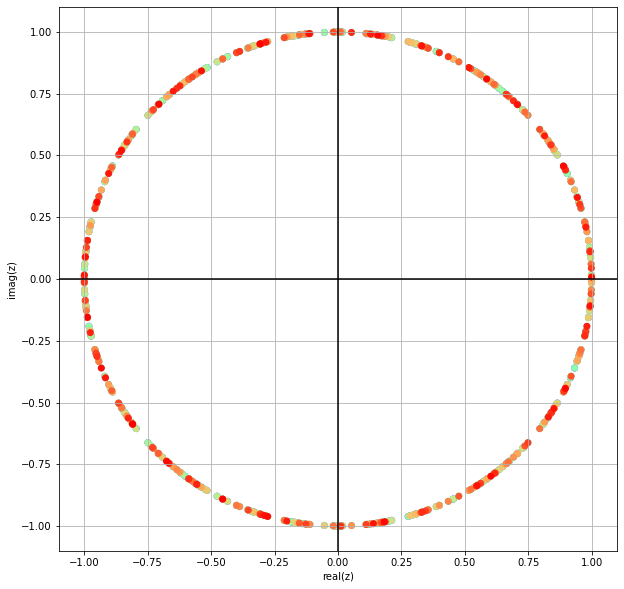

In [85]:
scatter_z(z_fm)